1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

2. Load Dataset

In [ ]:
df = pd.read_csv('ev_charging_sessions.csv')

print(df.head())
print(df.info())
print(df.describe())

         date  start_hour      city station_id  charger_kw  session_minutes  \
0  2025-03-04          20   Houston     ST0013         150               42   
1  2021-01-31          16    Denver     ST0115          11               76   
2  2019-02-24          15     Osaka     ST0380         100               35   
3  2018-12-23          15  Helsinki     ST0217           7               24   
4  2018-05-03          23   Chicago     ST0112          11               40   

   energy_kwh  price_per_kwh  session_cost  grid_load_mw  peak_hour  
0       26.28           0.33          8.67       4888.04          1  
1       30.96           0.19          5.88       5215.11          0  
2       23.41           0.09          2.11       4031.18          0  
3       22.45           0.16          3.59       4183.65          0  
4       23.14           0.12          2.78       4780.36          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns)

3. Check Missing Values

In [ ]:
print(df.isnull().sum())

date               0
start_hour         0
city               0
station_id         0
charger_kw         0
session_minutes    0
energy_kwh         0
price_per_kwh      0
session_cost       0
grid_load_mw       0
peak_hour          0
dtype: int64


4. Convert Date Column

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

print(df.head())

        date  start_hour      city station_id  charger_kw  session_minutes  \
0 2025-03-04          20   Houston     ST0013         150               42   
1 2021-01-31          16    Denver     ST0115          11               76   
2 2019-02-24          15     Osaka     ST0380         100               35   
3 2018-12-23          15  Helsinki     ST0217           7               24   
4 2018-05-03          23   Chicago     ST0112          11               40   

   energy_kwh  price_per_kwh  session_cost  grid_load_mw  peak_hour  year  \
0       26.28           0.33          8.67       4888.04          1  2025   
1       30.96           0.19          5.88       5215.11          0  2021   
2       23.41           0.09          2.11       4031.18          0  2019   
3       22.45           0.16          3.59       4183.65          0  2018   
4       23.14           0.12          2.78       4780.36          0  2018   

   month day_of_week  
0      3     Tuesday  
1      1      Sunday  

5. Create Charging Rate Variable

In [ ]:
df['charging_rate'] = df['energy_kwh'] / (df['session_minutes']/60)

print(df[['charger_kw','charging_rate']].head())

   charger_kw  charging_rate
0         150      37.542857
1          11      24.442105
2         100      40.131429
3           7      56.125000
4          11      34.710000


6. Distribution of Session Duration

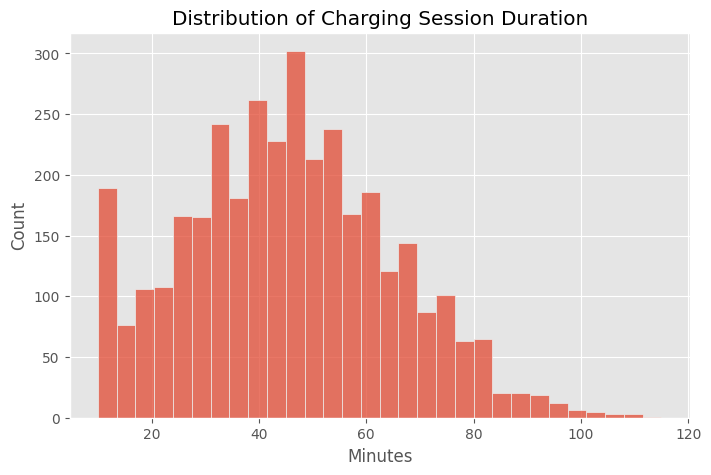

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['session_minutes'], bins=30)
plt.title('Distribution of Charging Session Duration')
plt.xlabel('Minutes')
plt.show()

7. Distribution of Energy Charged

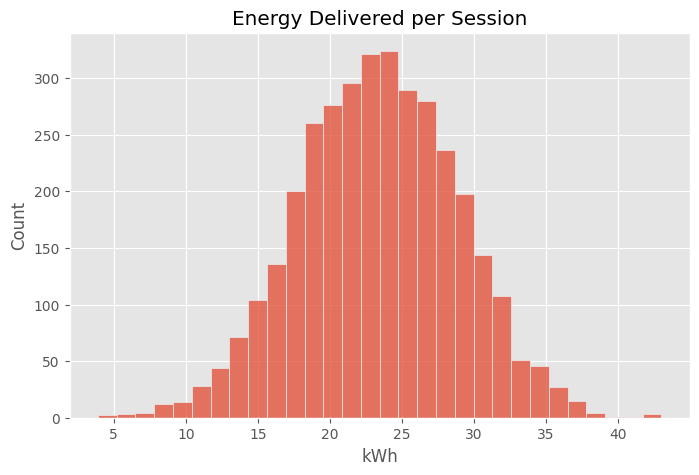

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['energy_kwh'], bins=30)
plt.title('Energy Delivered per Session')
plt.xlabel('kWh')
plt.show()

8. Charger Power vs Energy Delivered

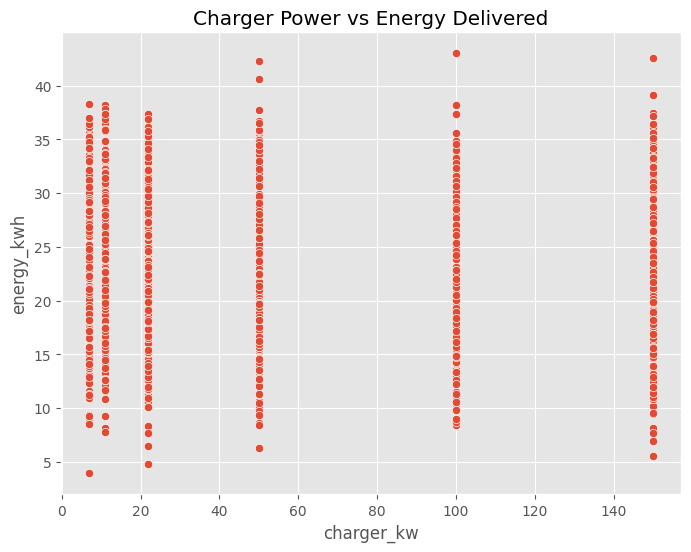

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='charger_kw',
    y='energy_kwh'
)

plt.title('Charger Power vs Energy Delivered')
plt.show()

9. Average Charging Time by Charger Type

charger_kw
7      44.707231
11     45.618280
22     44.834495
50     46.064250
100    45.599309
150    45.432520
Name: session_minutes, dtype: float64


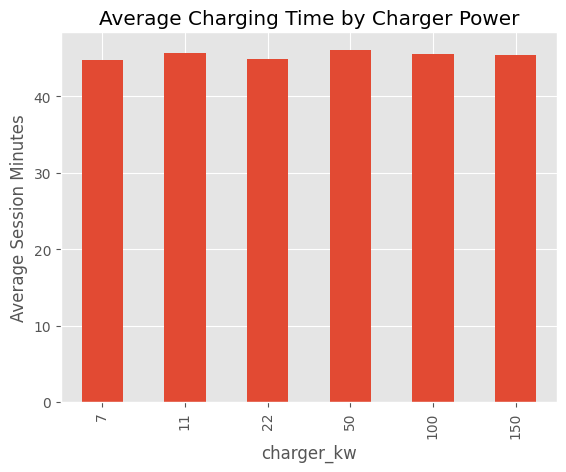

In [ ]:
charger_summary = df.groupby('charger_kw')['session_minutes'].mean()

print(charger_summary)

charger_summary.plot(kind='bar')
plt.ylabel('Average Session Minutes')
plt.title('Average Charging Time by Charger Power')
plt.show()

10. Peak vs Off-Peak Charging

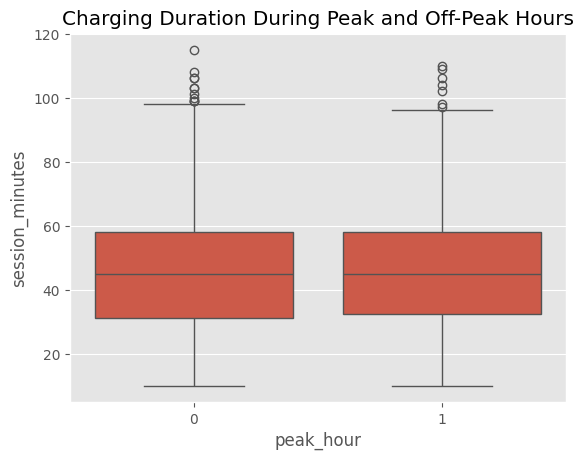

In [ ]:
sns.boxplot(
    data=df,
    x='peak_hour',
    y='session_minutes'
)

plt.title('Charging Duration During Peak and Off-Peak Hours')
plt.show()

11. Correlation Matrix

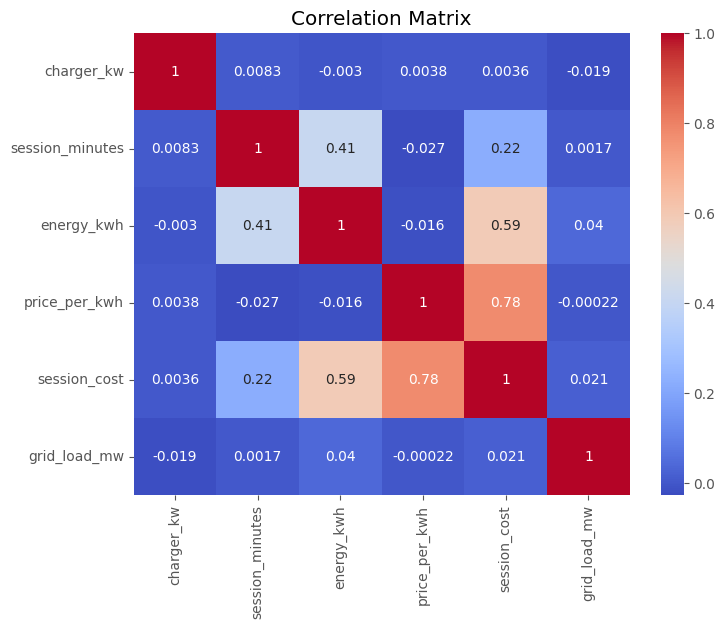

In [ ]:
# Useful for identifying factors affecting charging time.
numeric_cols = [
    'charger_kw',
    'session_minutes',
    'energy_kwh',
    'price_per_kwh',
    'session_cost',
    'grid_load_mw'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

12. Analysis

In [ ]:
df['miles_added'] = df['energy_kwh'] * 4
#(assuming approximately 4 miles/kWh)
df['minutes_per_mile'] = (
    df['session_minutes'] /
    df['miles_added']
)
#This helps estimate- How much journey range is gained per minute of charging? which directly relates to optimal stop durations.

13. First Research Model

In [ ]:
#regression model to predict charging time.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['charger_kw',
        'energy_kwh',
        'grid_load_mw',
        'peak_hour']]

y = df['session_minutes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("R² Score:", model.score(X_test,y_test))

R² Score: 0.16976472698561862


Battery Discharge During Journey

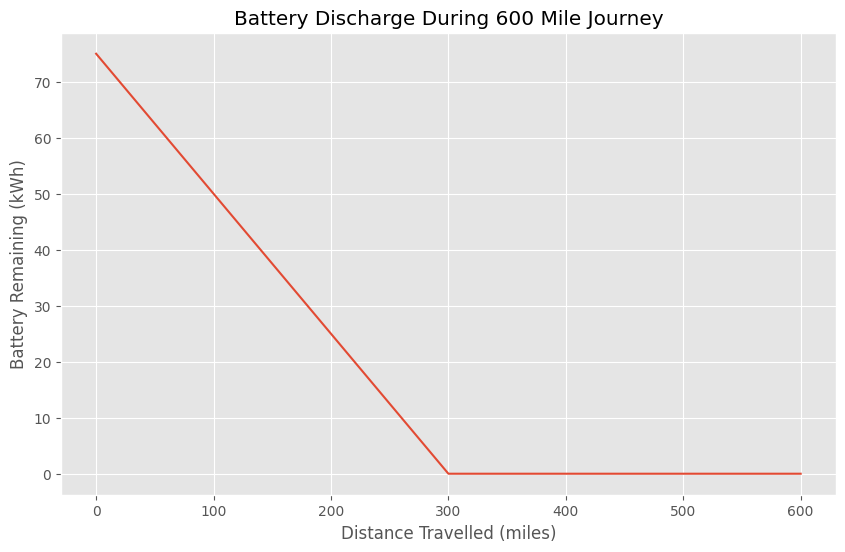

In [ ]:

battery_capacity = 75      # kWh
efficiency = 4             # miles per kWh
journey_distance = 600     # miles

distance = np.arange(0, journey_distance + 1, 10)

battery_remaining = battery_capacity - (distance / efficiency)

battery_remaining = np.maximum(battery_remaining, 0)

plt.figure(figsize=(10,6))

plt.plot(distance, battery_remaining)

plt.xlabel("Distance Travelled (miles)")
plt.ylabel("Battery Remaining (kWh)")
plt.title("Battery Discharge During 600 Mile Journey")

plt.grid(True)
plt.show()

Battery Charge Curve

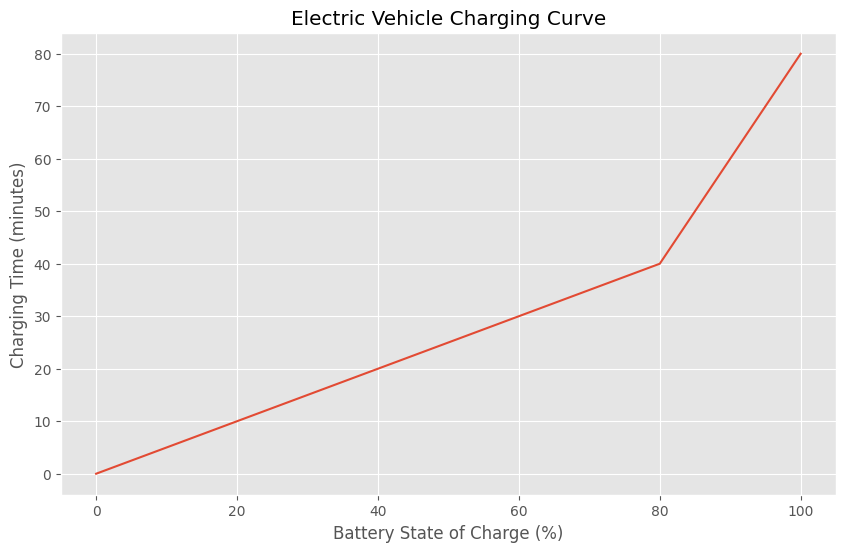

In [ ]:
soc = np.arange(0,101,1)

charge_time = []

for s in soc:

    if s <= 80:
        time = s * 0.5

    else:
        time = 40 + (s-80)*2

    charge_time.append(time)

plt.figure(figsize=(10,6))

plt.plot(soc, charge_time)

plt.xlabel("Battery State of Charge (%)")
plt.ylabel("Charging Time (minutes)")
plt.title("Electric Vehicle Charging Curve")

plt.grid(True)
plt.show()

Charge and Discharge Combined

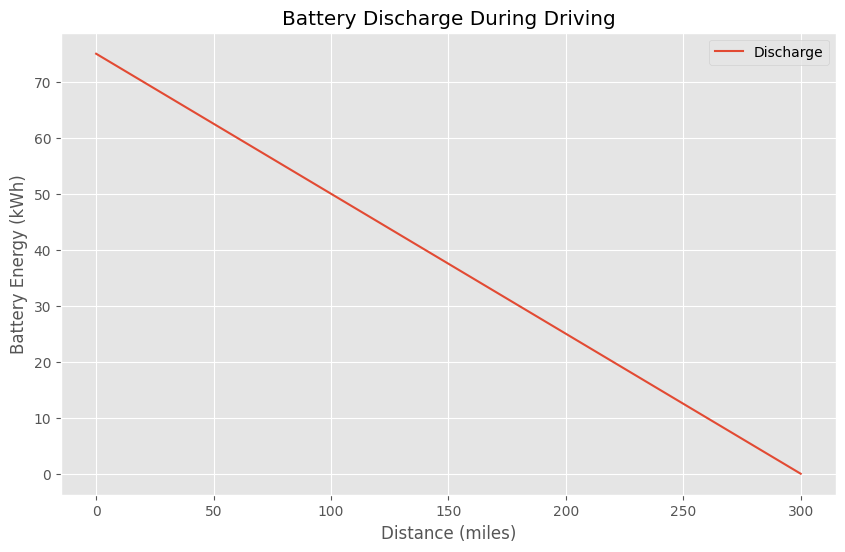

In [ ]:
battery_capacity = 75
efficiency = 4

distance = np.arange(0,301,5)

battery_level = (
    battery_capacity -
    (distance/efficiency)
)

battery_level = np.maximum(
    battery_level,
    0
)

plt.figure(figsize=(10,6))

plt.plot(
    distance,
    battery_level,
    label='Discharge'
)

plt.xlabel("Distance (miles)")
plt.ylabel("Battery Energy (kWh)")
plt.title("Battery Discharge During Driving")

plt.legend()
plt.grid(True)
plt.show()

Charging Time for Different Energy Requirements

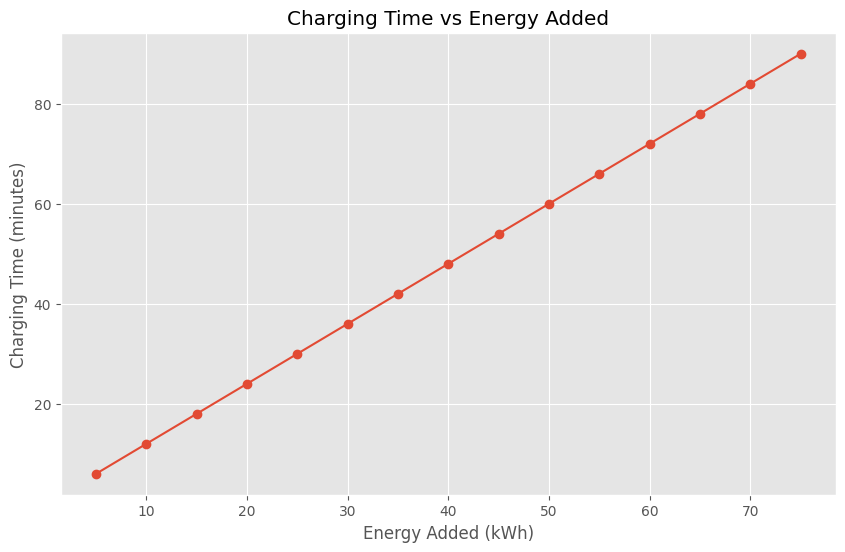

In [ ]:
avg_charge_rate = 50

energy_needed = np.arange(5,76,5)

charging_time = (
    energy_needed /
    avg_charge_rate
) * 60

plt.figure(figsize=(10,6))

plt.plot(
    energy_needed,
    charging_time,
    marker='o'
)

plt.xlabel("Energy Added (kWh)")
plt.ylabel("Charging Time (minutes)")
plt.title("Charging Time vs Energy Added")

plt.grid(True)
plt.show()

Summary Table of Charge and Discharge Times

In [ ]:
battery_capacity = 75
efficiency = 4
charge_rate = 50

distances = [50,100,150,200,250,300]

results = []

for d in distances:

    energy_used = d / efficiency

    charge_time = (
        energy_used /
        charge_rate
    ) * 60

    results.append([
        d,
        round(energy_used,2),
        round(charge_time,2)
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Distance (miles)",
        "Energy Used (kWh)",
        "Recharge Time (minutes)"
    ]
)

print(results)

   Distance (miles)  Energy Used (kWh)  Recharge Time (minutes)
0                50               12.5                     15.0
1               100               25.0                     30.0
2               150               37.5                     45.0
3               200               50.0                     60.0
4               250               62.5                     75.0
5               300               75.0                     90.0


Speed of car VS efficiency

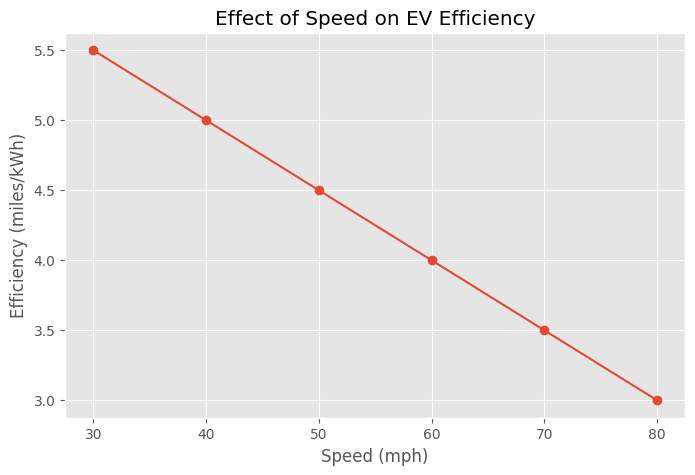

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

speed = [30,40,50,60,70,80]
efficiency = [5.5,5.0,4.5,4.0,3.5,3.0]

plt.figure(figsize=(8,5))

plt.plot(speed, efficiency, marker='o')

plt.xlabel("Speed (mph)")
plt.ylabel("Efficiency (miles/kWh)")
plt.title("Effect of Speed on EV Efficiency")

plt.grid(True)
plt.show()

Battery Discharge for Different Speeds

In [ ]:
battery_capacity = 75
journey_distance = 300


battery_capacity = 75
journey_distance = 300

speed = [30,40,50,60,70,80]
efficiency = [5.5,5.0,4.5,4.0,3.5,3.0]

results = []

for s,e in zip(speed,efficiency):

    energy_used = journey_distance / e

    battery_remaining = (
        battery_capacity -
        energy_used
    )

    results.append([
        s,
        e,
        energy_used,
        battery_remaining
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Speed (mph)",
        "Efficiency (miles/kWh)",
        "Energy Used (kWh)",
        "Battery Remaining (kWh)"
    ]
)

print(results)

   Speed (mph)  Efficiency (miles/kWh)  Energy Used (kWh)  \
0           30                     5.5          54.545455   
1           40                     5.0          60.000000   
2           50                     4.5          66.666667   
3           60                     4.0          75.000000   
4           70                     3.5          85.714286   
5           80                     3.0         100.000000   

   Battery Remaining (kWh)  
0                20.454545  
1                15.000000  
2                 8.333333  
3                 0.000000  
4               -10.714286  
5               -25.000000  


Graph: Speed vs Battery Consumption

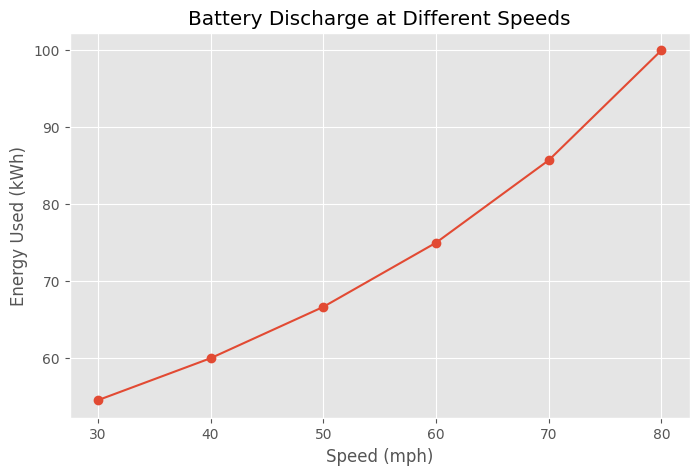

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results["Speed (mph)"],
    results["Energy Used (kWh)"],
    marker='o'
)

plt.xlabel("Speed (mph)")
plt.ylabel("Energy Used (kWh)")
plt.title("Battery Discharge at Different Speeds")

plt.grid(True)
plt.show()

Graph: Speed vs Remaining Battery

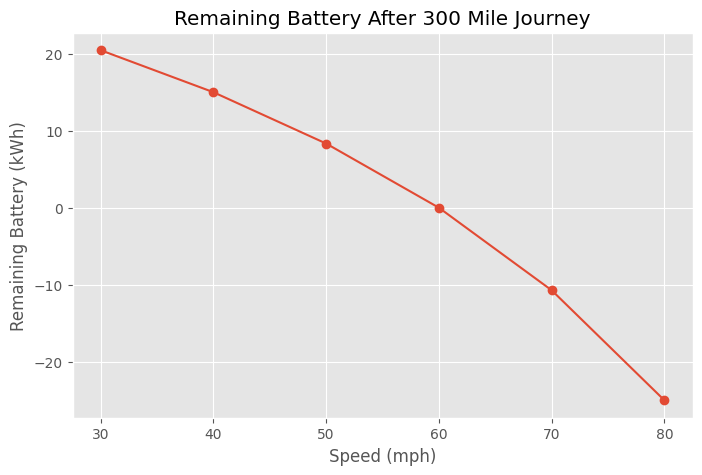

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    results["Speed (mph)"],
    results["Battery Remaining (kWh)"],
    marker='o'
)

plt.xlabel("Speed (mph)")
plt.ylabel("Remaining Battery (kWh)")
plt.title("Remaining Battery After 300 Mile Journey")

plt.grid(True)
plt.show()

Energy Consumption

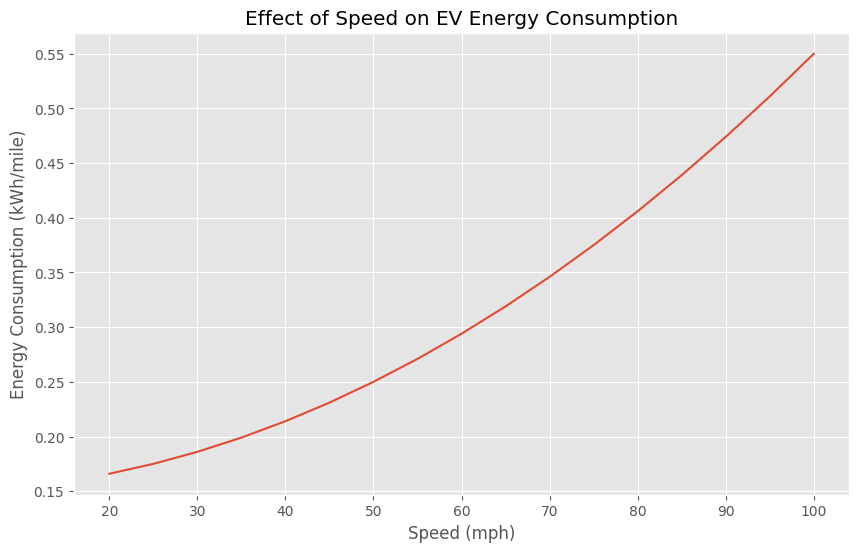

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

speed = np.arange(20,101,5)

energy_consumption = (
    0.15 +
    0.00004*(speed**2)
)

plt.figure(figsize=(10,6))

plt.plot(
    speed,
    energy_consumption
)

plt.xlabel("Speed (mph)")
plt.ylabel("Energy Consumption (kWh/mile)")
plt.title("Effect of Speed on EV Energy Consumption")

plt.grid(True)
plt.show()

Spped effecing EV range

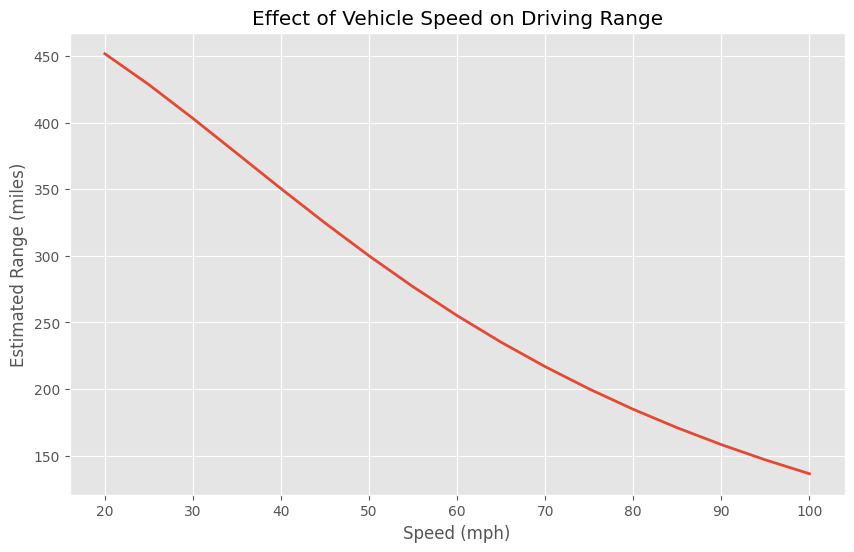

In [ ]:
battery_capacity = 75

speed = np.arange(20,101,5)

energy_consumption = (
    0.15 +
    0.00004*(speed**2)
)

range_miles = (
    battery_capacity /
    energy_consumption
)

plt.figure(figsize=(10,6))

plt.plot(
    speed,
    range_miles,
    linewidth=2
)

plt.xlabel("Speed (mph)")
plt.ylabel("Estimated Range (miles)")
plt.title("Effect of Vehicle Speed on Driving Range")

plt.grid(True)
plt.show()

We are going to analyse a 600‑mile journey by exploring multiple scenarios, focusing on how different driving speeds and charging levels affect overall efficiency. By comparing these variations, we aim to determine which combination provides the most effective and energy‑efficient outcome for long‑distance travel

##Scenario 1
we begin by driving 300 miles at a constant speed of 50 mph. After completing this first segment, the vehicle is charged to 100%. Once fully charged, we continue the journey for another 300 miles. The total journey time is then calculated by combining the driving duration for both segments and the time required to recharge the vehicle.

NOTE: For the simulation, efficiency values were assumed to decrease with increasing vehicle speed. These values were selected to represent the general behaviour of electric vehicles, where higher speeds result in greater energy consumption and lower driving efficiency.

In [ ]:
import pandas as pd

# Vehicle parameters
battery_capacity = 75      # kWh
speed = 50                 # mph
distance_leg = 300         # miles

# Efficiency at 50 mph
efficiency = 4.5           # miles/kWh

# Average charging rate from dataset
charging_rate = 50         # kW

# -----------------------------
# First 300 miles
# -----------------------------

energy_used_leg1 = distance_leg / efficiency

battery_remaining = (
    battery_capacity -
    energy_used_leg1
)

battery_percentage = (
    battery_remaining /
    battery_capacity
) * 100

driving_time_leg1 = (
    distance_leg /
    speed
)

# -----------------------------
# Charging back to 100%
# -----------------------------

energy_to_recharge = (
    battery_capacity -
    battery_remaining
)

charging_time = (
    energy_to_recharge /
    charging_rate
)

charging_time_minutes = (
    charging_time * 60
)

# -----------------------------
# Second 300 miles
# -----------------------------

energy_used_leg2 = distance_leg / efficiency

driving_time_leg2 = (
    distance_leg /
    speed
)

# -----------------------------
# Journey totals
# -----------------------------

total_distance = 600

total_driving_time = (
    driving_time_leg1 +
    driving_time_leg2
)

total_journey_time = (
    total_driving_time +
    charging_time
)

# -----------------------------
# Results
# -----------------------------

results = pd.DataFrame({

    "Metric":[
        "Distance Driven Before Charging",
        "Battery Remaining",
        "Battery Remaining %",
        "Energy Required To Recharge",
        "Charging Time (minutes)",
        "Driving Time First 300 Miles (hours)",
        "Driving Time Second 300 Miles (hours)",
        "Total Driving Time (hours)",
        "Total Journey Time (hours)"
    ],

    "Value":[
        distance_leg,
        round(battery_remaining,2),
        round(battery_percentage,2),
        round(energy_to_recharge,2),
        round(charging_time_minutes,2),
        round(driving_time_leg1,2),
        round(driving_time_leg2,2),
        round(total_driving_time,2),
        round(total_journey_time,2)
    ]

})

print(results)

                                  Metric   Value
0        Distance Driven Before Charging  300.00
1                      Battery Remaining    8.33
2                    Battery Remaining %   11.11
3            Energy Required To Recharge   66.67
4                Charging Time (minutes)   80.00
5   Driving Time First 300 Miles (hours)    6.00
6  Driving Time Second 300 Miles (hours)    6.00
7             Total Driving Time (hours)   12.00
8             Total Journey Time (hours)   13.33


##Scenario 2
the journey is divided into three equal segments of 200 miles. We begin by driving the first 200 miles at a constant speed of 50 mph, after which the vehicle is charged to 80%. The second 200‑mile segment is then completed, followed by another charge to 80%. Finally, the last 200 miles are driven. The total journey time is determined by combining the driving durations for all three segments along with the charging times at each stop.


In [ ]:
import pandas as pd

# Vehicle parameters
battery_capacity = 75      # kWh
speed = 50                 # mph
distance_leg = 200         # miles

# Efficiency at 50 mph
efficiency = 4.5           # miles/kWh

# Average charging rate
charging_rate = 50         # kW

# -----------------------------
# First 200 miles
# -----------------------------

energy_used_leg1 = distance_leg / efficiency

battery_remaining_leg1 = (
    battery_capacity -
    energy_used_leg1
)

battery_percentage_leg1 = (
    battery_remaining_leg1 /
    battery_capacity
) * 100

driving_time_leg1 = (
    distance_leg /
    speed
)

# -----------------------------
# Charge to 80%
# -----------------------------

target_battery = (
    0.80 *
    battery_capacity
)

energy_to_recharge_leg1 = (
    target_battery -
    battery_remaining_leg1
)

charging_time_leg1 = (
    energy_to_recharge_leg1 /
    charging_rate
)

charging_time_leg1_minutes = (
    charging_time_leg1 * 60
)

# -----------------------------
# Second 200 miles
# -----------------------------

energy_used_leg2 = distance_leg / efficiency

battery_remaining_leg2 = (
    target_battery -
    energy_used_leg2
)

battery_percentage_leg2 = (
    battery_remaining_leg2 /
    battery_capacity
) * 100

driving_time_leg2 = (
    distance_leg /
    speed
)

# -----------------------------
# Charge to 80% Again
# -----------------------------

energy_to_recharge_leg2 = (
    target_battery -
    battery_remaining_leg2
)

charging_time_leg2 = (
    energy_to_recharge_leg2 /
    charging_rate
)

charging_time_leg2_minutes = (
    charging_time_leg2 * 60
)

# -----------------------------
# Third 200 miles
# -----------------------------

energy_used_leg3 = distance_leg / efficiency

battery_remaining_leg3 = (
    target_battery -
    energy_used_leg3
)

battery_percentage_leg3 = (
    battery_remaining_leg3 /
    battery_capacity
) * 100

driving_time_leg3 = (
    distance_leg /
    speed
)

# -----------------------------
# Journey totals
# -----------------------------

total_distance = 600

total_driving_time = (
    driving_time_leg1 +
    driving_time_leg2 +
    driving_time_leg3
)

total_charging_time = (
    charging_time_leg1 +
    charging_time_leg2
)

total_journey_time = (
    total_driving_time +
    total_charging_time
)

# -----------------------------
# Results
# -----------------------------

results = pd.DataFrame({

    "Metric":[
        "Battery Remaining After First 200 Miles (kWh)",
        "Battery Remaining After First 200 Miles (%)",
        "Charge Time To 80% After First 200 Miles (minutes)",

        "Battery Remaining After Second 200 Miles (kWh)",
        "Battery Remaining After Second 200 Miles (%)",
        "Charge Time To 80% After Second 200 Miles (minutes)",

        "Battery Remaining After Final 200 Miles (kWh)",
        "Battery Remaining After Final 200 Miles (%)",

        "Driving Time First 200 Miles (hours)",
        "Driving Time Second 200 Miles (hours)",
        "Driving Time Third 200 Miles (hours)",

        "Total Driving Time (hours)",
        "Total Charging Time (hours)",
        "Total Journey Time (hours)"
    ],

    "Value":[
        round(battery_remaining_leg1,2),
        round(battery_percentage_leg1,2),
        round(charging_time_leg1_minutes,2),

        round(battery_remaining_leg2,2),
        round(battery_percentage_leg2,2),
        round(charging_time_leg2_minutes,2),

        round(battery_remaining_leg3,2),
        round(battery_percentage_leg3,2),

        round(driving_time_leg1,2),
        round(driving_time_leg2,2),
        round(driving_time_leg3,2),

        round(total_driving_time,2),
        round(total_charging_time,2),
        round(total_journey_time,2)
    ]

})

print(results)

                                               Metric  Value
0       Battery Remaining After First 200 Miles (kWh)  30.56
1         Battery Remaining After First 200 Miles (%)  40.74
2   Charge Time To 80% After First 200 Miles (minu...  35.33
3      Battery Remaining After Second 200 Miles (kWh)  15.56
4        Battery Remaining After Second 200 Miles (%)  20.74
5   Charge Time To 80% After Second 200 Miles (min...  53.33
6       Battery Remaining After Final 200 Miles (kWh)  15.56
7         Battery Remaining After Final 200 Miles (%)  20.74
8                Driving Time First 200 Miles (hours)   4.00
9               Driving Time Second 200 Miles (hours)   4.00
10               Driving Time Third 200 Miles (hours)   4.00
11                         Total Driving Time (hours)  12.00
12                        Total Charging Time (hours)   1.48
13                         Total Journey Time (hours)  13.48


##Scenario 3

Now we will start the journey with 100% charge and drive it till 0% and then charge it 100% then till 0% continues........
Here in this scenario we will drive with the speed of 30 mile/ per hour,40 mile/ per hour, 50 mile/ per hour, 60 mile/ per hour, 70 mile/ per hour, 80 mile/ per hour

Speed= 30mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 30                     # mph
efficiency = 5.5               # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed          # hours

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate   # hours

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time (Hours)",
        "Action"
    ]
)

print(results)

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time (hours):", round(total_driving_time,2))
print("Charging Time (hours):", round(total_charging_time,2))
print("Total Journey Time (hours):", round(total_driving_time + total_charging_time,2))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time (Hours)  \
0     1                       412.5                   412.5         13.75   
1     2                         0.0                   412.5          1.50   
2     3                       187.5                   600.0          6.25   

   Action  
0   Drive  
1  Charge  
2   Drive  

Summary
--------------------------
Charging Stops : 1
Driving Time (hours): 20.0
Charging Time (hours): 1.5
Total Journey Time (hours): 21.5


Speed = 40mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 40                     # mph
efficiency = 5.0               # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

def hrs_mins(hours):
    """Turn decimal hours into a '2h 30m' style string."""
    h = int(hours)
    m = round((hours - h) * 60)
    if m == 60:
        h += 1
        m = 0
    return f"{h}h {m}m"

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed          # hours

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        round(driving_time*60,1),
        hrs_mins(driving_time),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate   # hours

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            round(charging_time*60,1),
            hrs_mins(charging_time),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time (Hours)",
        "Time (Minutes)",
        "Time (H:M)",
        "Action"
    ]
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print(results)

total_time = total_driving_time + total_charging_time

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time :", round(total_driving_time,2), "hours =", round(total_driving_time*60,1), "minutes =", hrs_mins(total_driving_time))
print("Charging Time :", round(total_charging_time,2), "hours =", round(total_charging_time*60,1), "minutes =", hrs_mins(total_charging_time))
print("Total Journey Time :", round(total_time,2), "hours =", round(total_time*60,1), "minutes =", hrs_mins(total_time))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time (Hours)  Time (Minutes) Time (H:M)  Action
0     1                       375.0                   375.0          9.38           562.5     9h 22m   Drive
1     2                         0.0                   375.0          1.50            90.0     1h 30m  Charge
2     3                       225.0                   600.0          5.62           337.5     5h 38m   Drive

Summary
--------------------------
Charging Stops : 1
Driving Time : 15.0 hours = 900.0 minutes = 15h 0m
Charging Time : 1.5 hours = 90.0 minutes = 1h 30m
Total Journey Time : 16.5 hours = 990.0 minutes = 16h 30m


Speed = 50mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 50                     # mph
efficiency = 4.5               # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

def hrs_mins(hours):
    """Turn decimal hours into a '2h 30m' style string."""
    h = int(hours)
    m = round((hours - h) * 60)
    if m == 60:
        h += 1
        m = 0
    return f"{h}h {m}m"

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed          # hours

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        round(driving_time*60,1),
        hrs_mins(driving_time),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate   # hours

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            round(charging_time*60,1),
            hrs_mins(charging_time),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time (Hours)",
        "Time (Minutes)",
        "Time (H:M)",
        "Action"
    ]
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print(results)

total_time = total_driving_time + total_charging_time

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time :", round(total_driving_time,2), "hours =", round(total_driving_time*60,1), "minutes =", hrs_mins(total_driving_time))
print("Charging Time :", round(total_charging_time,2), "hours =", round(total_charging_time*60,1), "minutes =", hrs_mins(total_charging_time))
print("Total Journey Time :", round(total_time,2), "hours =", round(total_time*60,1), "minutes =", hrs_mins(total_time))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time (Hours)  Time (Minutes) Time (H:M)  Action
0     1                       337.5                   337.5          6.75           405.0     6h 45m   Drive
1     2                         0.0                   337.5          1.50            90.0     1h 30m  Charge
2     3                       262.5                   600.0          5.25           315.0     5h 15m   Drive

Summary
--------------------------
Charging Stops : 1
Driving Time : 12.0 hours = 720.0 minutes = 12h 0m
Charging Time : 1.5 hours = 90.0 minutes = 1h 30m
Total Journey Time : 13.5 hours = 810.0 minutes = 13h 30m


Speed = 60mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 60                     # mph
efficiency = 4.0              # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time",
        "Action"
    ]
)

print(results)

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time (hours):", round(total_driving_time,2))
print("Charging Time (hours):", round(total_charging_time,2))
print("Total Journey Time (hours):", round(total_driving_time + total_charging_time,2))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time  Action
0     1                       300.0                   300.0   5.0   Drive
1     2                         0.0                   300.0   1.5  Charge
2     3                       300.0                   600.0   5.0   Drive

Summary
--------------------------
Charging Stops : 1
Driving Time (hours): 10.0
Charging Time (hours): 1.5
Total Journey Time (hours): 11.5


Speed = 70mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 70                     # mph
efficiency = 3.5               # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time",
        "Action"
    ]
)

print(results)

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time (hours):", round(total_driving_time,2))
print("Charging Time (hours):", round(total_charging_time,2))
print("Total Journey Time (hours):", round(total_driving_time + total_charging_time,2))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time  Action
0     1                       262.5                   262.5  3.75   Drive
1     2                         0.0                   262.5  1.50  Charge
2     3                       262.5                   525.0  3.75   Drive
3     4                         0.0                   525.0  1.50  Charge
4     5                        75.0                   600.0  1.07   Drive

Summary
--------------------------
Charging Stops : 2
Driving Time (hours): 8.57
Charging Time (hours): 3.0
Total Journey Time (hours): 11.57


Speed = 80mph

In [ ]:
import pandas as pd

# Vehicle Parameters
battery_capacity = 75          # kWh
speed = 80                     # mph
efficiency = 3.0               # miles/kWh
charging_rate = 50             # kW
destination = 600              # miles

# Battery range on one full charge
range_per_charge = battery_capacity * efficiency

distance_travelled = 0
total_driving_time = 0
total_charging_time = 0
charging_stops = 0

journey = []

while distance_travelled < destination:

    remaining_distance = destination - distance_travelled

    distance_this_leg = min(range_per_charge, remaining_distance)

    driving_time = distance_this_leg / speed

    distance_travelled += distance_this_leg

    total_driving_time += driving_time

    journey.append([
        len(journey)+1,
        round(distance_this_leg,2),
        round(distance_travelled,2),
        round(driving_time,2),
        "Drive"
    ])

    if distance_travelled < destination:

        charging_time = battery_capacity / charging_rate

        total_charging_time += charging_time

        charging_stops += 1

        journey.append([
            len(journey)+1,
            0,
            round(distance_travelled,2),
            round(charging_time,2),
            "Charge"
        ])

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Distance Travelled (Miles)",
        "Total Distance (Miles)",
        "Time",
        "Action"
    ]
)

print(results)

print("\nSummary")
print("--------------------------")
print("Charging Stops :", charging_stops)
print("Driving Time (hours):", round(total_driving_time,2))
print("Charging Time (hours):", round(total_charging_time,2))
print("Total Journey Time (hours):", round(total_driving_time + total_charging_time,2))

   Step  Distance Travelled (Miles)  Total Distance (Miles)  Time  Action
0     1                       225.0                   225.0  2.81   Drive
1     2                         0.0                   225.0  1.50  Charge
2     3                       225.0                   450.0  2.81   Drive
3     4                         0.0                   450.0  1.50  Charge
4     5                       150.0                   600.0  1.88   Drive

Summary
--------------------------
Charging Stops : 2
Driving Time (hours): 7.5
Charging Time (hours): 3.0
Total Journey Time (hours): 10.5


Comparison Table for all the speeds

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Speed (mph)" : [30,40,50,60,70,80],

    "Range per Charge (miles)" :
    [412.5,375,337.5,300,262.5,225],

    "Charging Stops" :
    [1,1,1,1,2,2],

    "Driving Time (hours)" :
    [20,15,12,10,8.57,7.50],

    "Charging Time (hours)" :
    [1.5,1.5,1.5,1.5,3.0,3.0],

    "Total Journey Time (hours)" :
    [21.5,16.5,13.5,11.5,11.57,10.5]

})

print(comparison)

   Speed (mph)  Range per Charge (miles)  Charging Stops  Driving Time (hours)  Charging Time (hours)  Total Journey Time (hours)
0           30                     412.5               1                 20.00                    1.5                       21.50
1           40                     375.0               1                 15.00                    1.5                       16.50
2           50                     337.5               1                 12.00                    1.5                       13.50
3           60                     300.0               1                 10.00                    1.5                       11.50
4           70                     262.5               2                  8.57                    3.0                       11.57
5           80                     225.0               2                  7.50                    3.0                       10.50


Graphs for all the  values together

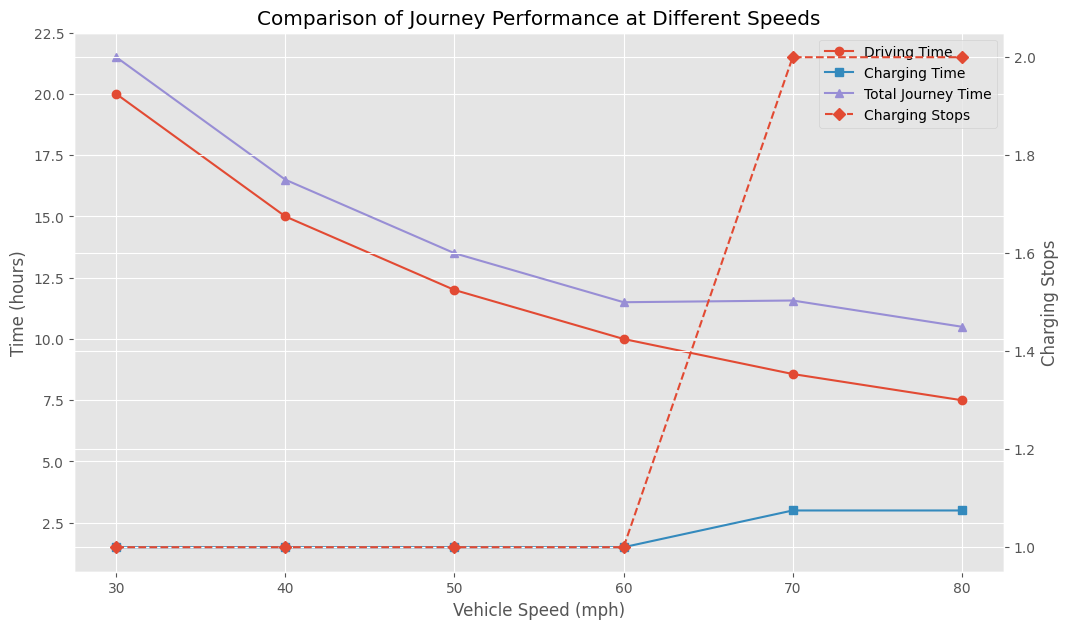

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Speed": [30,40,50,60,70,80],
    "Driving Time": [20,15,12,10,8.57,7.50],
    "Charging Time": [1.5,1.5,1.5,1.5,3.0,3.0],
    "Total Journey Time": [21.5,16.5,13.5,11.5,11.57,10.5],
    "Charging Stops": [1,1,1,1,2,2],
    "Range": [412.5,375,337.5,300,262.5,225]
})

fig, ax1 = plt.subplots(figsize=(12,7))

ax1.plot(comparison["Speed"], comparison["Driving Time"], marker='o', label="Driving Time")
ax1.plot(comparison["Speed"], comparison["Charging Time"], marker='s', label="Charging Time")
ax1.plot(comparison["Speed"], comparison["Total Journey Time"], marker='^', label="Total Journey Time")

ax1.set_xlabel("Vehicle Speed (mph)")
ax1.set_ylabel("Time (hours)")

ax2 = ax1.twinx()

ax2.plot(comparison["Speed"], comparison["Charging Stops"],
         marker='D',
         linestyle='--',
         label="Charging Stops")

ax2.set_ylabel("Charging Stops")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Comparison of Journey Performance at Different Speeds")
plt.grid(True)

plt.show()

## Scenario 4
Now we will start the journey with 100% charge and drive it till 20% and then charge it 100% then till 20% continues........ till we reach our destination of 600 miles,Here in this scenario we will drive with the speed of 30 mile/ per hour,40 mile/ per hour, 50 mile/ per hour, 60 mile/ per hour, 70 mile/ per hour, 80 mile/ per hour

Speed = 30mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 30
efficiency = 5.5
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     330.0           330.0         20  11.0
1     2  Charge       0.0           330.0        100   1.2
2     3   Drive     270.0           600.0         20   9.0

Charging Stops: 1
Driving Time: 20.0 hours
Charging Time: 1.2 hours
Total Journey Time: 21.2 hours


Speed = 40mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 40
efficiency = 5.0
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     300.0           300.0         20   7.5
1     2  Charge       0.0           300.0        100   1.2
2     3   Drive     300.0           600.0         20   7.5

Charging Stops: 1
Driving Time: 15.0 hours
Charging Time: 1.2 hours
Total Journey Time: 16.2 hours


Speed = 50mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 50
efficiency = 4.5
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     270.0           270.0         20   5.4
1     2  Charge       0.0           270.0        100   1.2
2     3   Drive     270.0           540.0         20   5.4
3     4  Charge       0.0           540.0        100   1.2
4     5   Drive      60.0           600.0         20   1.2

Charging Stops: 2
Driving Time: 12.0 hours
Charging Time: 2.4 hours
Total Journey Time: 14.4 hours


Speed = 60mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 60
efficiency = 4.0
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     240.0           240.0         20   4.0
1     2  Charge       0.0           240.0        100   1.2
2     3   Drive     240.0           480.0         20   4.0
3     4  Charge       0.0           480.0        100   1.2
4     5   Drive     120.0           600.0         20   2.0

Charging Stops: 2
Driving Time: 10.0 hours
Charging Time: 2.4 hours
Total Journey Time: 12.4 hours


Speed = 70mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 70
efficiency = 3.5
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     210.0           210.0         20  3.00
1     2  Charge       0.0           210.0        100  1.20
2     3   Drive     210.0           420.0         20  3.00
3     4  Charge       0.0           420.0        100  1.20
4     5   Drive     180.0           600.0         20  2.57

Charging Stops: 2
Driving Time: 8.57 hours
Charging Time: 2.4 hours
Total Journey Time: 10.97 hours


Speed = 80mph

In [ ]:
import pandas as pd

battery_capacity = 75
usable_battery = battery_capacity * 0.80

speed = 80
efficiency = 3.0
charging_rate = 50
destination = 600

range_per_charge = usable_battery * efficiency

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey=[]

while distance_travelled < destination:

    remaining = destination-distance_travelled

    distance = min(range_per_charge,remaining)

    drive_time = distance/speed

    distance_travelled += distance

    driving_time += drive_time

    battery_remaining = 20

    journey.append([
        len(journey)+1,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        battery_remaining,
        round(drive_time,2)
    ])

    if distance_travelled < destination:

        charge=(usable_battery/charging_rate)

        charging_time+=charge

        charging_stops+=1

        journey.append([
            len(journey)+1,
            "Charge",
            0,
            round(distance_travelled,2),
            100,
            round(charge,2)
        ])

results=pd.DataFrame(journey,
columns=[
"Step",
"Action",
"Distance",
"Total Distance",
"Battery %",
"Time"
])

print(results)

print("\nCharging Stops:",charging_stops)
print("Driving Time:",round(driving_time,2),"hours")
print("Charging Time:",round(charging_time,2),"hours")
print("Total Journey Time:",round(driving_time+charging_time,2),"hours")

   Step  Action  Distance  Total Distance  Battery %  Time
0     1   Drive     180.0           180.0         20  2.25
1     2  Charge       0.0           180.0        100  1.20
2     3   Drive     180.0           360.0         20  2.25
3     4  Charge       0.0           360.0        100  1.20
4     5   Drive     180.0           540.0         20  2.25
5     6  Charge       0.0           540.0        100  1.20
6     7   Drive      60.0           600.0         20  0.75

Charging Stops: 3
Driving Time: 7.5 hours
Charging Time: 3.6 hours
Total Journey Time: 11.1 hours


Comparison Table

In [ ]:
import pandas as pd

comparison=pd.DataFrame({

"Speed":[30,40,50,60,70,80],

"Range per Charge":[330,300,270,240,210,180],

"Charging Stops":[1,1,2,2,2,3],

"Driving Time":[20,15,12,10,8.57,7.50],

"Charging Time":[1.2,1.2,2.4,2.4,2.4,3.6],

"Total Journey Time":[21.2,16.2,14.4,12.4,10.97,11.10]

})

print(comparison)

   Speed  Range per Charge  Charging Stops  Driving Time  Charging Time  Total Journey Time
0     30               330               1         20.00            1.2               21.20
1     40               300               1         15.00            1.2               16.20
2     50               270               2         12.00            2.4               14.40
3     60               240               2         10.00            2.4               12.40
4     70               210               2          8.57            2.4               10.97
5     80               180               3          7.50            3.6               11.10


Comparison Graph

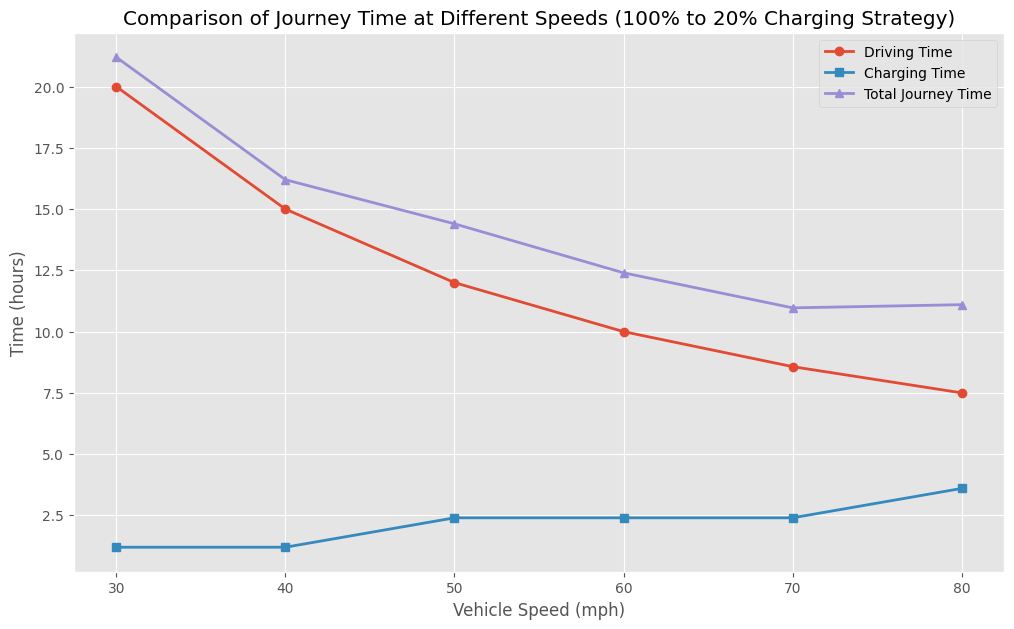

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.plot(
    comparison["Speed"],
    comparison["Driving Time"],
    marker='o',
    linewidth=2,
    label="Driving Time"
)

plt.plot(
    comparison["Speed"],
    comparison["Charging Time"],
    marker='s',
    linewidth=2,
    label="Charging Time"
)

plt.plot(
    comparison["Speed"],
    comparison["Total Journey Time"],
    marker='^',
    linewidth=2,
    label="Total Journey Time"
)

plt.xlabel("Vehicle Speed (mph)")
plt.ylabel("Time (hours)")
plt.title("Comparison of Journey Time at Different Speeds (100% to 20% Charging Strategy)")

plt.xticks(comparison["Speed"])

plt.grid(True)

plt.legend()

plt.show()

## Scenario 5
Now we will start the journey with 100% charge and drive it till 0% and then charge it 80% then drive  till 0% then charge till 80% continues........ till we reach our destination of 600 miles,Here in this scenario we will drive with the speed of 30 mile/ per hour,40 mile/ per hour, 50 mile/ per hour, 60 mile/ per hour, 70 mile/ per hour, 80 mile/ per hour


Speed = 30 mph

In [ ]:
import pandas as pd


speed = 30
efficiency = 5.5


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)   Time
0     1   Drive                      412.5                   412.5                       0  13.75
1     2  Charge                        0.0                   412.5                      80   1.20
2     3   Drive                      187.5                   600.0                       0   6.25

-------------------------------
Speed: 30 mph
Efficiency: 5.5 miles/kWh
Range on First Charge: 412.5 miles
Range on 80% Charge: 330.0 miles
Charging Stops: 1
Driving Time: 20.0 hours
Charging Time: 1.2 hours
Total Journey Time: 21.2 hours


Speed = 40mph

In [ ]:
import pandas as pd


speed = 40
efficiency = 5.0


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                      375.0                   375.0                       0  9.38
1     2  Charge                        0.0                   375.0                      80  1.20
2     3   Drive                      225.0                   600.0                       0  5.62

-------------------------------
Speed: 40 mph
Efficiency: 5.0 miles/kWh
Range on First Charge: 375.0 miles
Range on 80% Charge: 300.0 miles
Charging Stops: 1
Driving Time: 15.0 hours
Charging Time: 1.2 hours
Total Journey Time: 16.2 hours


Speed = 50mph

In [ ]:
import pandas as pd


speed = 50
efficiency = 4.5


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                      337.5                   337.5                       0  6.75
1     2  Charge                        0.0                   337.5                      80  1.20
2     3   Drive                      262.5                   600.0                       0  5.25

-------------------------------
Speed: 50 mph
Efficiency: 4.5 miles/kWh
Range on First Charge: 337.5 miles
Range on 80% Charge: 270.0 miles
Charging Stops: 1
Driving Time: 12.0 hours
Charging Time: 1.2 hours
Total Journey Time: 13.2 hours


Speed = 60mph

In [ ]:
import pandas as pd


speed = 60
efficiency = 4.0


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                      300.0                   300.0                       0   5.0
1     2  Charge                        0.0                   300.0                      80   1.2
2     3   Drive                      240.0                   540.0                       0   4.0
3     4  Charge                        0.0                   540.0                      80   1.2
4     5   Drive                       60.0                   600.0                       0   1.0

-------------------------------
Speed: 60 mph
Efficiency: 4.0 miles/kWh
Range on First Charge: 300.0 miles
Range on 80% Charge: 240.0 miles
Charging Stops: 2
Driving Time: 10.0 hours
Charging Time: 2.4 hours
Total Journey Time: 12.4 hours


Speed = 70mph

In [ ]:
import pandas as pd


speed = 70
efficiency = 3.5


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")
results_list = []

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                      262.5                   262.5                       0  3.75
1     2  Charge                        0.0                   262.5                      80  1.20
2     3   Drive                      210.0                   472.5                       0  3.00
3     4  Charge                        0.0                   472.5                      80  1.20
4     5   Drive                      127.5                   600.0                       0  1.82

-------------------------------
Speed: 70 mph
Efficiency: 3.5 miles/kWh
Range on First Charge: 262.5 miles
Range on 80% Charge: 210.0 miles
Charging Stops: 2
Driving Time: 8.57 hours
Charging Time: 2.4 hours
Total Journey Time: 10.97 hours


Speed = 80mph

In [ ]:
import pandas as pd


speed = 80
efficiency = 3.0


battery_capacity = 75       # kWh
charging_rate = 50          # kW
destination = 600           # miles

distance = 0

driving_time = 0

charging_time = 0

charging_stops = 0

journey=[]

battery_energy = battery_capacity

step = 1

while distance < destination:

    # Range available with current battery

    range_available = battery_energy * efficiency

    remaining = destination - distance

    drive = min(range_available,remaining)

    drive_time = drive / speed

    distance += drive

    driving_time += drive_time

    battery_remaining = 0

    journey.append([
        step,
        "Drive",
        round(drive,2),
        round(distance,2),
        battery_remaining,
        round(drive_time,2)
    ])

    step += 1

    if distance >= destination:
        break

    # Charge to 80%

    battery_energy = battery_capacity * 0.80

    charge_energy = battery_energy

    charge_time = (charge_energy / charging_rate)

    charging_time += charge_time

    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance,2),
        80,
        round(charge_time,2)
    ])

    step += 1

results = pd.DataFrame(

journey,

columns=[

"Step",

"Action",

"Distance This Leg (Miles)",

"Total Distance (Miles)",

"Battery After Step (%)",

"Time"

]

)

print(results)

print("\n-------------------------------")

print("Speed:",speed,"mph")

print("Efficiency:",efficiency,"miles/kWh")

print("Range on First Charge:",
      round(75*efficiency,2),"miles")

print("Range on 80% Charge:",
      round(60*efficiency,2),"miles")

print("Charging Stops:",charging_stops)

print("Driving Time:",
      round(driving_time,2),"hours")

print("Charging Time:",
      round(charging_time,2),"hours")

print("Total Journey Time:",
      round(driving_time+charging_time,2),"hours")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                      225.0                   225.0                       0  2.81
1     2  Charge                        0.0                   225.0                      80  1.20
2     3   Drive                      180.0                   405.0                       0  2.25
3     4  Charge                        0.0                   405.0                      80  1.20
4     5   Drive                      180.0                   585.0                       0  2.25
5     6  Charge                        0.0                   585.0                      80  1.20
6     7   Drive                       15.0                   600.0                       0  0.19

-------------------------------
Speed: 80 mph
Efficiency: 3.0 miles/kWh
Range on First Charge: 225.0 miles
Range on 80% Charge: 180.0 miles
Charging Stops: 3
Driving Time: 7.5 hours
Charging Time: 3.6 hours
Total Journey Ti

comparison table

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Speed (mph)" : [30,40,50,60,70,80],

    "Efficiency (miles/kWh)" : [5.5,5.0,4.5,4.0,3.5,3.0],

    "Range on First Charge (miles)" :
    [412.5,375,337.5,300,262.5,225],

    "Range on 80% Charge (miles)" :
    [330,300,270,240,210,180],

    "Charging Stops" :
    [1,1,1,2,2,3],

    "Driving Time (hours)" :
    [20.00,15.00,12.00,10.00,8.57,7.50],

    "Charging Time (hours)" :
    [1.20,1.20,1.20,2.40,2.40,3.60],

    "Total Journey Time (hours)" :
    [21.20,16.20,13.20,12.40,10.97,11.10]

})

print(comparison)

   Speed (mph)  Efficiency (miles/kWh)  Range on First Charge (miles)  Range on 80% Charge (miles)  Charging Stops  Driving Time (hours)  Charging Time (hours)  Total Journey Time (hours)
0           30                     5.5                          412.5                          330               1                 20.00                    1.2                       21.20
1           40                     5.0                          375.0                          300               1                 15.00                    1.2                       16.20
2           50                     4.5                          337.5                          270               1                 12.00                    1.2                       13.20
3           60                     4.0                          300.0                          240               2                 10.00                    2.4                       12.40
4           70                     3.5                      

comparison graph

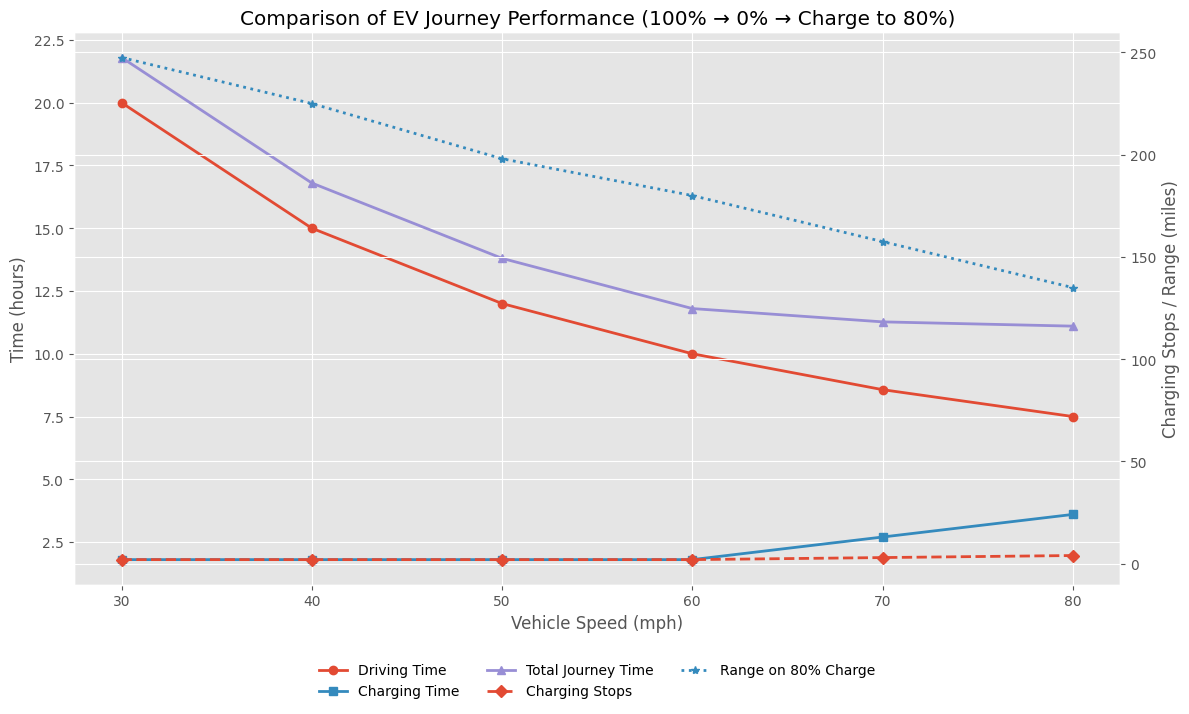

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,7))

# -------------------------------
# Time graphs
# -------------------------------

ax1.plot(
    comparison["Speed (mph)"],
    comparison["Driving Time (hours)"],
    marker='o',
    linewidth=2,
    label="Driving Time"
)

ax1.plot(
    comparison["Speed (mph)"],
    comparison["Charging Time (hours)"],
    marker='s',
    linewidth=2,
    label="Charging Time"
)

ax1.plot(
    comparison["Speed (mph)"],
    comparison["Total Journey Time (hours)"],
    marker='^',
    linewidth=2,
    label="Total Journey Time"
)

ax1.set_xlabel("Vehicle Speed (mph)")
ax1.set_ylabel("Time (hours)")

# -------------------------------
# Second Axis
# -------------------------------

ax2 = ax1.twinx()

ax2.plot(
    comparison["Speed (mph)"],
    comparison["Charging Stops"],
    marker='D',
    linestyle='--',
    linewidth=2,
    label="Charging Stops"
)

ax2.plot(
    comparison["Speed (mph)"],
    comparison["Range on 80% Charge (miles)"],
    marker='*',
    linestyle=':',
    linewidth=2,
    label="Range on 80% Charge"
)

ax2.set_ylabel("Charging Stops / Range (miles)")

# -------------------------------
# Legend
# -------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)
plt.tight_layout()

plt.title("Comparison of EV Journey Performance (100% → 0% → Charge to 80%)")

plt.grid(True)

plt.show()

## Scenario 6
Now we will start the journey with 100% charge and drive it till 20% and then charge it 80% then drive  till 20% then charge till 80% continues........ till we reach our destination of 600 miles,Here in this scenario we will drive with the speed of 30 mile/ per hour,40 mile/ per hour, 50 mile/ per hour, 60 mile/ per hour, 70 mile/ per hour, 80 mile/ per hour

Speed = 30mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 30                 # mph
efficiency = 5.5           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)   Time
0     1   Drive                      330.0                   330.0           20  11.00
1     2  Charge                        0.0                   330.0           80   0.90
2     3   Drive                      247.5                   577.5           20   8.25
3     4  Charge                        0.0                   577.5           80   0.90
4     5   Drive                       22.5                   600.0           20   0.75

-----SUMMARY-----
Speed: 30 mph
Charging Stops: 2
Driving Time: 20.0 hours
Charging Time: 1.8 hours
Total Journey Time: 21.8 hours
Range on First Charge: 330.0 miles
Range on 80% Charge: 247.5 miles


Speed = 40mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 40                 # mph
efficiency = 5.0           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)  Time
0     1   Drive                      300.0                   300.0           20  7.50
1     2  Charge                        0.0                   300.0           80  0.90
2     3   Drive                      225.0                   525.0           20  5.62
3     4  Charge                        0.0                   525.0           80  0.90
4     5   Drive                       75.0                   600.0           20  1.88

-----SUMMARY-----
Speed: 40 mph
Charging Stops: 2
Driving Time: 15.0 hours
Charging Time: 1.8 hours
Total Journey Time: 16.8 hours
Range on First Charge: 300.0 miles
Range on 80% Charge: 225.0 miles


Speed = 50mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 50                 # mph
efficiency = 4.4           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)  Time
0     1   Drive                      264.0                   264.0           20  5.28
1     2  Charge                        0.0                   264.0           80  0.90
2     3   Drive                      198.0                   462.0           20  3.96
3     4  Charge                        0.0                   462.0           80  0.90
4     5   Drive                      138.0                   600.0           20  2.76

-----SUMMARY-----
Speed: 50 mph
Charging Stops: 2
Driving Time: 12.0 hours
Charging Time: 1.8 hours
Total Journey Time: 13.8 hours
Range on First Charge: 264.0 miles
Range on 80% Charge: 198.0 miles


Speed = 60mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 60                 # mph
efficiency = 4.0           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)  Time
0     1   Drive                      240.0                   240.0           20   4.0
1     2  Charge                        0.0                   240.0           80   0.9
2     3   Drive                      180.0                   420.0           20   3.0
3     4  Charge                        0.0                   420.0           80   0.9
4     5   Drive                      180.0                   600.0           20   3.0

-----SUMMARY-----
Speed: 60 mph
Charging Stops: 2
Driving Time: 10.0 hours
Charging Time: 1.8 hours
Total Journey Time: 11.8 hours
Range on First Charge: 240.0 miles
Range on 80% Charge: 180.0 miles


Speed = 70mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 70                 # mph
efficiency = 3.5           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)  Time
0     1   Drive                      210.0                   210.0           20  3.00
1     2  Charge                        0.0                   210.0           80  0.90
2     3   Drive                      157.5                   367.5           20  2.25
3     4  Charge                        0.0                   367.5           80  0.90
4     5   Drive                      157.5                   525.0           20  2.25
5     6  Charge                        0.0                   525.0           80  0.90
6     7   Drive                       75.0                   600.0           20  1.07

-----SUMMARY-----
Speed: 70 mph
Charging Stops: 3
Driving Time: 8.57 hours
Charging Time: 2.7 hours
Total Journey Time: 11.27 hours
Range on First Charge: 210.0 miles
Range on 80% Charge: 157.5 miles


Speed = 80mph

In [ ]:
import pandas as pd

battery_capacity = 75      # kWh
speed = 80                 # mph
efficiency = 3.0           # miles/kWh
charging_rate = 50         # kW
destination = 600          # miles

usable_first = battery_capacity * 0.80      # 100% → 20%
usable_after = battery_capacity * 0.60      # 80% → 20%

distance_travelled = 0
driving_time = 0
charging_time = 0
charging_stops = 0

journey = []

step = 1
first_trip = True

while distance_travelled < destination:

    if first_trip:
        usable_energy = usable_first
    else:
        usable_energy = usable_after

    range_available = usable_energy * efficiency

    remaining_distance = destination - distance_travelled

    distance = min(range_available, remaining_distance)

    drive_time = distance / speed

    distance_travelled += distance
    driving_time += drive_time

    journey.append([
        step,
        "Drive",
        round(distance,2),
        round(distance_travelled,2),
        20,
        round(drive_time,2)
    ])

    step += 1

    if distance_travelled >= destination:
        break

    charge_energy = battery_capacity * 0.60

    charge_time = charge_energy / charging_rate

    charging_time += charge_time
    charging_stops += 1

    journey.append([
        step,
        "Charge",
        0,
        round(distance_travelled,2),
        80,
        round(charge_time,2)
    ])

    step += 1
    first_trip = False

results = pd.DataFrame(
    journey,
    columns=[
        "Step",
        "Action",
        "Distance This Leg (Miles)",
        "Total Distance (Miles)",
        "Battery (%)",
        "Time"
    ]
)

print(results)

print("\n-----SUMMARY-----")
print("Speed:", speed, "mph")
print("Charging Stops:", charging_stops)
print("Driving Time:", round(driving_time,2), "hours")
print("Charging Time:", round(charging_time,2), "hours")
print("Total Journey Time:", round(driving_time+charging_time,2), "hours")
print("Range on First Charge:", round(usable_first*efficiency,2), "miles")
print("Range on 80% Charge:", round(usable_after*efficiency,2), "miles")

   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery (%)  Time
0     1   Drive                      180.0                   180.0           20  2.25
1     2  Charge                        0.0                   180.0           80  0.90
2     3   Drive                      135.0                   315.0           20  1.69
3     4  Charge                        0.0                   315.0           80  0.90
4     5   Drive                      135.0                   450.0           20  1.69
5     6  Charge                        0.0                   450.0           80  0.90
6     7   Drive                      135.0                   585.0           20  1.69
7     8  Charge                        0.0                   585.0           80  0.90
8     9   Drive                       15.0                   600.0           20  0.19

-----SUMMARY-----
Speed: 80 mph
Charging Stops: 4
Driving Time: 7.5 hours
Charging Time: 3.6 hours
Total Journey Time: 11.1 hours
Range on 

Comparison table

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Speed (mph)": [30, 40, 50, 60, 70, 80],

    "Range on First Charge (miles)": [
        330.0 ,300.0, 264.0, 240.0, 210.0, 180.0
        ],

    "Range on 80% Charge (miles)": [
        247.5, 225.0, 198.0, 180.0, 157.5, 135.0
    ],

    "Charging Stops": [
        2, 2, 2, 2, 3, 4
    ],

    "Driving Time (hours)": [
        20.0, 15.0, 12.0, 10.0, 8.57, 7.5
    ],

    "Charging Time (hours)": [
        1.8, 1.8, 1.8, 1.8, 2.7, 3.6
    ],

    "Total Journey Time (hours)": [
        21.8, 16.8, 13.8, 11.8, 11.27, 11.1
    ]

})

print(comparison)

   Speed (mph)  Range on First Charge (miles)  Range on 80% Charge (miles)  Charging Stops  Driving Time (hours)  Charging Time (hours)  Total Journey Time (hours)
0           30                          330.0                        247.5               2                 20.00                    1.8                       21.80
1           40                          300.0                        225.0               2                 15.00                    1.8                       16.80
2           50                          264.0                        198.0               2                 12.00                    1.8                       13.80
3           60                          240.0                        180.0               2                 10.00                    1.8                       11.80
4           70                          210.0                        157.5               3                  8.57                    2.7                       11.27
5           80  

comparsion graph

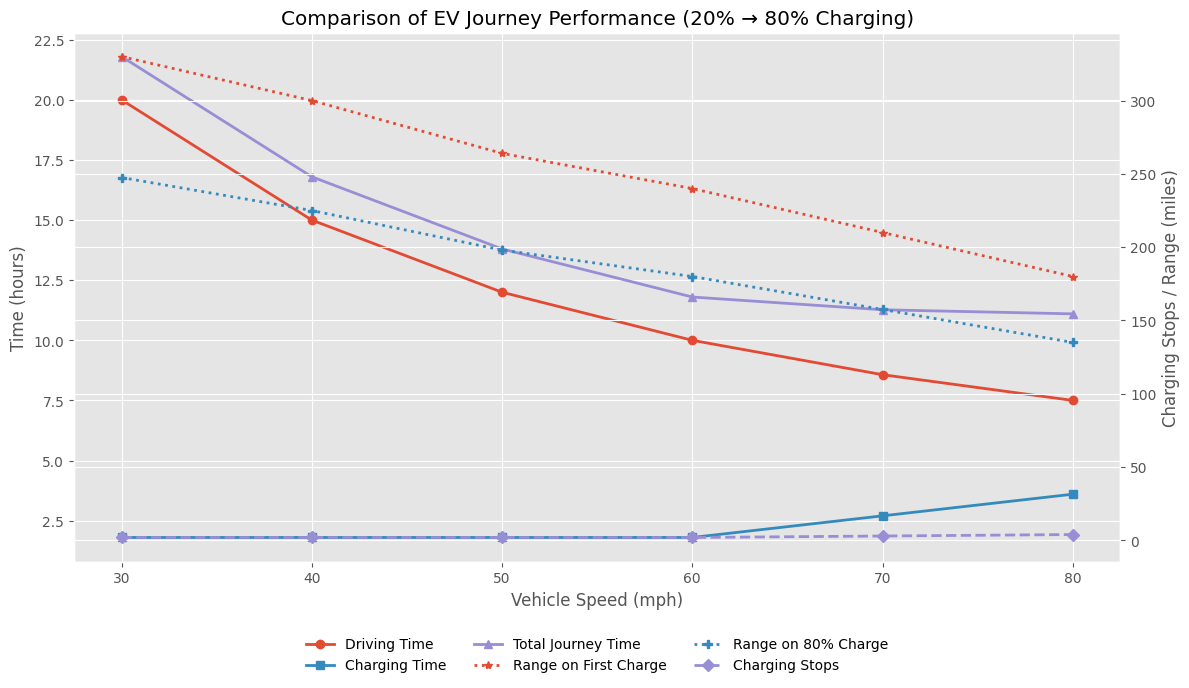

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,7))

# Time-related (left axis)
ax1.plot(comparison["Speed (mph)"], comparison["Driving Time (hours)"],
         marker='o', linewidth=2, label="Driving Time")
ax1.plot(comparison["Speed (mph)"], comparison["Charging Time (hours)"],
         marker='s', linewidth=2, label="Charging Time")
ax1.plot(comparison["Speed (mph)"], comparison["Total Journey Time (hours)"],
         marker='^', linewidth=2, label="Total Journey Time")

ax1.set_xlabel("Vehicle Speed (mph)")
ax1.set_ylabel("Time (hours)")

# Range and stops (right axis)
ax2 = ax1.twinx()
ax2.plot(comparison["Speed (mph)"], comparison["Range on First Charge (miles)"],
         marker='*', linestyle=':', linewidth=2, label="Range on First Charge")
ax2.plot(comparison["Speed (mph)"], comparison["Range on 80% Charge (miles)"],
         marker='P', linestyle=':', linewidth=2, label="Range on 80% Charge")
ax2.plot(comparison["Speed (mph)"], comparison["Charging Stops"],
         marker='D', linestyle='--', linewidth=2, label="Charging Stops")

ax2.set_ylabel("Charging Stops / Range (miles)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper center", bbox_to_anchor=(0.5, -0.12),
           ncol=3, frameon=False)

plt.title("Comparison of EV Journey Performance (20% → 80% Charging)")
plt.xticks(comparison["Speed (mph)"])
ax1.grid(True)
plt.tight_layout()
plt.show()

##Scenario 7
Now we simulate the 600 mile journey with **randomised** driving and charging behaviour instead of a fixed rule.

- We start the journey at **100%** charge.
- On every driving leg we drive until the battery reaches a **random point between 0% and 50%**.
- At every charging stop we then charge back up to a **random point between 50% and 100%**.
- This is repeated until the 600 mile destination is reached.
- We repeat this random journey many times (trials) for every speed (30, 40, 50, 60, 70, 80 mph), and every time a trial produces a **shorter total journey time than the current best time for that speed, we keep the new time as the best time**.
- Finally we compare the best time obtained at every speed to find the single best time for the whole 600 mile journey.

In [ ]:
import pandas as pd
import numpy as np
import random

# -----------------------------
# Vehicle / journey parameters
# -----------------------------
battery_capacity = 75          # kWh
charging_rate = 50             # kW
destination = 600              # miles

speeds = [30, 40, 50, 60, 70, 80]
efficiencies = [5.5, 5.0, 4.5, 4.0, 3.5, 3.0]   # miles/kWh (same as earlier scenarios)

n_trials = 200      # number of random journeys simulated per speed
random.seed(42)     # keeps the random results reproducible


def simulate_journey(speed, efficiency):
    """Simulate one random 600 mile journey at a given speed.
    Drive until a random 0-50% charge remains, then charge to a
    random 50-100%, repeat until destination is reached."""

    distance_travelled = 0
    battery_pct = 100.0          # start at 100% charge
    total_driving_time = 0       # hours
    total_charging_time = 0      # hours
    charging_stops = 0
    journey = []
    step = 1

    while distance_travelled < destination:

        # ---- Drive until a random point between 0% and 50% ----
        discharge_to = random.uniform(0, 50)

        usable_pct = battery_pct - discharge_to
        usable_energy = battery_capacity * (usable_pct / 100)
        range_available = usable_energy * efficiency

        remaining_distance = destination - distance_travelled
        distance_this_leg = min(range_available, remaining_distance)

        drive_time = distance_this_leg / speed

        distance_travelled += distance_this_leg
        total_driving_time += drive_time

        if distance_this_leg < range_available:
            # reached destination before hitting the discharge target
            energy_used = distance_this_leg / efficiency
            battery_pct = battery_pct - (energy_used / battery_capacity) * 100
        else:
            battery_pct = discharge_to

        journey.append([
            step, "Drive", round(distance_this_leg, 2),
            round(distance_travelled, 2), round(battery_pct, 1),
            round(drive_time, 2)
        ])
        step += 1

        if distance_travelled >= destination:
            break

        # ---- Charge up to a random point between 50% and 100% ----
        charge_to = random.uniform(50, 100)

        energy_to_recharge = battery_capacity * (charge_to - battery_pct) / 100
        charge_time = energy_to_recharge / charging_rate   # hours

        total_charging_time += charge_time
        charging_stops += 1
        battery_pct = charge_to

        journey.append([
            step, "Charge", 0, round(distance_travelled, 2),
            round(battery_pct, 1), round(charge_time , 2)
        ])
        step += 1

    total_time = total_driving_time + total_charging_time

    return total_time, total_driving_time, total_charging_time, charging_stops, journey


# -----------------------------
# Run many random trials for every speed
# -----------------------------
speed_best_time = {}       # best (minimum) journey time found for each speed
speed_best_journey = {}    # the journey log that produced that best time
speed_all_times = {}       # every trial's time, for each speed

best_overall = {"time": float("inf")}

for speed, efficiency in zip(speeds, efficiencies):

    best_time = float("inf")
    best_journey = None
    trial_times = []

    print(f"\n=== Speed = {speed} mph ===")

    for trial in range(1, n_trials + 1):

        total_time, drive_t, charge_t, stops, journey = simulate_journey(speed, efficiency)
        trial_times.append(round(total_time, 3))

        # Keep the new time only if it beats the current best time
        if total_time < best_time:
            best_time = total_time
            best_journey = journey
            print(f"Trial {trial}: new best time for {speed} mph -> {round(best_time,3)} hours")

    speed_best_time[speed] = round(best_time, 3)
    speed_best_journey[speed] = best_journey
    speed_all_times[speed] = trial_times

    if best_time < best_overall["time"]:
        best_overall = {
            "time": round(best_time, 3),
            "speed": speed,
            "journey": best_journey
        }

print("\nAll speeds simulated.")


=== Speed = 30 mph ===
Trial 1: new best time for 30 mph -> 21.705 hours
Trial 2: new best time for 30 mph -> 21.001 hours
Trial 3: new best time for 30 mph -> 20.965 hours
Trial 14: new best time for 30 mph -> 20.963 hours
Trial 27: new best time for 30 mph -> 20.802 hours
Trial 68: new best time for 30 mph -> 20.78 hours
Trial 134: new best time for 30 mph -> 20.714 hours

=== Speed = 40 mph ===
Trial 1: new best time for 40 mph -> 16.866 hours
Trial 5: new best time for 40 mph -> 16.395 hours
Trial 7: new best time for 40 mph -> 16.315 hours
Trial 8: new best time for 40 mph -> 16.055 hours
Trial 77: new best time for 40 mph -> 16.009 hours
Trial 156: new best time for 40 mph -> 15.996 hours

=== Speed = 50 mph ===
Trial 1: new best time for 50 mph -> 13.79 hours
Trial 2: new best time for 50 mph -> 13.622 hours
Trial 4: new best time for 50 mph -> 13.342 hours
Trial 40: new best time for 50 mph -> 13.328 hours
Trial 65: new best time for 50 mph -> 13.295 hours
Trial 86: new best t

In [ ]:
### All trial times for every speed


In [ ]:
# Table showing every random trial's total journey time, for each speed
all_times_df = pd.DataFrame(speed_all_times)
all_times_df.index = [f"Trial {i+1}" for i in range(n_trials)]

print(all_times_df.head(10))   # first 10 trials shown, all_times_df holds every trial


              30      40      50      60      70      80
Trial 1   21.705  16.866  13.790  11.753  10.956  10.867
Trial 2   21.001  17.134  13.622  12.282  11.235  11.140
Trial 3   20.965  17.265  13.953  12.189  11.343  10.453
Trial 4   21.595  16.888  13.342  12.353  11.372  10.652
Trial 5   21.428  16.395  14.009  12.258  11.414  10.989
Trial 6   21.880  16.950  14.247  12.149  11.332  11.023
Trial 7   21.770  16.315  13.887  12.529  11.265  10.535
Trial 8   21.890  16.055  13.479  12.264  11.056  11.104
Trial 9   21.052  16.605  14.010  12.594  11.293  11.138
Trial 10  21.669  16.905  14.272  11.846  11.231  11.294


### Best time found at each speed

In [ ]:
summary = pd.DataFrame({
    "Speed (mph)": speeds,
    "Best Time (hours)": [speed_best_time[s] for s in speeds],
    "Worst Trial Time (hours)": [max(speed_all_times[s]) for s in speeds],
    "Average Trial Time (hours)": [round(np.mean(speed_all_times[s]), 3) for s in speeds]
})

print(summary)

   Speed (mph)  Best Time (hours)  Worst Trial Time (hours)  Average Trial Time (hours)
0           30             20.714                    22.105                      21.409
1           40             15.996                    17.366                      16.688
2           50             13.203                    14.566                      13.945
3           60             11.546                    12.949                      12.231
4           70             10.515                    11.970                      11.271
5           80             10.085                    11.464                      10.791


### Overall best time across all speeds

In [ ]:
print("BEST OVERALL JOURNEY")
print("---------------------------------")
print("Speed:", best_overall["speed"], "mph")
print("Best Total Journey Time:", best_overall["time"], "hours")

best_journey_df = pd.DataFrame(
    best_overall["journey"],
    columns=["Step", "Action", "Distance This Leg (Miles)",
             "Total Distance (Miles)", "Battery After Step (%)", "Time"]
)

print(best_journey_df)

BEST OVERALL JOURNEY
---------------------------------
Speed: 80 mph
Best Total Journey Time: 10.085 hours
   Step  Action  Distance This Leg (Miles)  Total Distance (Miles)  Battery After Step (%)  Time
0     1   Drive                     156.21                  156.21                    30.6  1.95
1     2  Charge                       0.00                  156.21                    83.9  0.80
2     3   Drive                      96.97                  253.18                    40.8  1.21
3     4  Charge                       0.00                  253.18                    74.4  0.50
4     5   Drive                      87.03                  340.21                    35.7  1.09
5     6  Charge                       0.00                  340.21                    76.4  0.61
6     7   Drive                     124.46                  464.67                    21.1  1.56
7     8  Charge                       0.00                  464.67                    65.8  0.67
8     9   Drive     

### Comparison graph: best time vs speed

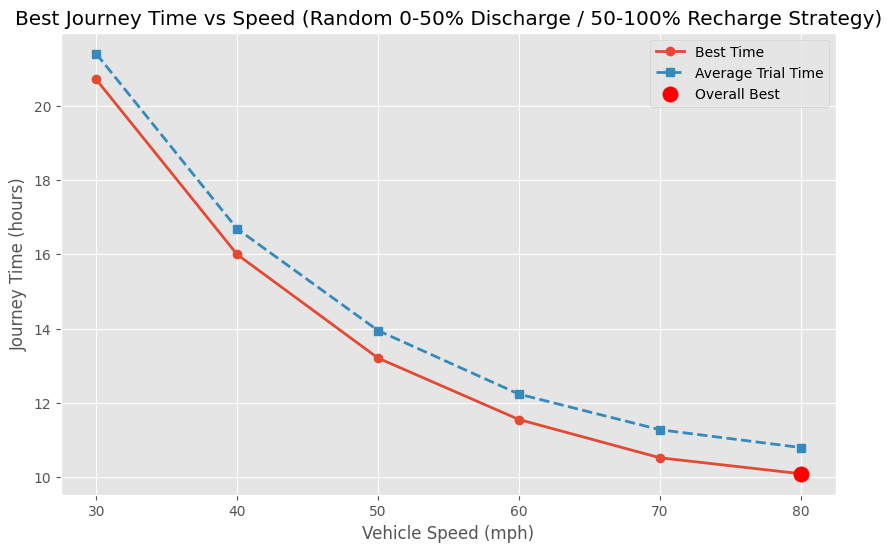

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(summary["Speed (mph)"], summary["Best Time (hours)"],
         marker='o', linewidth=2, label="Best Time")
plt.plot(summary["Speed (mph)"], summary["Average Trial Time (hours)"],
         marker='s', linestyle='--', linewidth=2, label="Average Trial Time")

plt.scatter([best_overall["speed"]], [best_overall["time"]],
            color='red', s=120, zorder=5, label="Overall Best")

plt.xlabel("Vehicle Speed (mph)")
plt.ylabel("Journey Time (hours)")
plt.title("Best Journey Time vs Speed (Random 0-50% Discharge / 50-100% Recharge Strategy)")
plt.xticks(summary["Speed (mph)"])
plt.legend()
plt.grid(True)
plt.show()

random numbers


In [ ]:
import pandas as pd
import numpy as np
import random

battery_capacity = 75          # kWh
charging_rate = 50             # kW
destination = 600              # miles

n_trials = 100
random.seed(42)

def efficiency_for_speed(speed):
    # (30,5.5)(40,5.0)(50,4.5)(60,4.0)(70,3.5)(80,3.0)
    return 7.0 - 0.05 * speed

def simulate_journey(speed, efficiency):
    distance_travelled = 0
    battery_pct = 100.0
    total_driving_time = 0
    total_charging_time = 0
    stops = []          # one entry per charging stop

    while distance_travelled < destination:
        discharge_to = random.uniform(0, 50)
        usable_pct = battery_pct - discharge_to
        usable_energy = battery_capacity * (usable_pct / 100)
        range_available = usable_energy * efficiency

        remaining_distance = destination - distance_travelled
        distance_this_leg = min(range_available, remaining_distance)
        drive_time = distance_this_leg / speed

        distance_travelled += distance_this_leg
        total_driving_time += drive_time

        if distance_this_leg < range_available:
            energy_used = distance_this_leg / efficiency
            battery_pct = battery_pct - (energy_used / battery_capacity) * 100
        else:
            battery_pct = discharge_to

        if distance_travelled >= destination:
            break

        # ---- Charging stop ----
        stopped_at_pct = battery_pct                      # % when the stop begins
        charge_to = random.uniform(50, 100)                # % charged up to
        energy_to_recharge = battery_capacity * (charge_to - stopped_at_pct) / 100
        charge_time_hr = energy_to_recharge / charging_rate
        charge_time_min = charge_time_hr
        total_charging_time += charge_time_hr

        stops.append({
            "Stop #": len(stops) + 1,
            "Distance at Stop (miles)": round(distance_travelled, 2),
            "Stopped at Charge (%)": round(stopped_at_pct, 1),
            "Charged Up To (%)": round(charge_to, 1),
            "Charging Duration (hours)": round(charge_time_min, 2)
        })

        battery_pct = charge_to

    total_time = total_driving_time + total_charging_time
    return total_time, total_driving_time, total_charging_time, stops

speeds = list(range(30, 81))

speed_results = []
speed_stops_detail = {}
best_overall = {"time": float("inf")}

for speed in speeds:
    efficiency = efficiency_for_speed(speed)
    best_time = float("inf")
    best_stops = None
    best_drive_t = None
    best_charge_t = None

    for trial in range(n_trials):
        total_time, drive_t, charge_t, stops = simulate_journey(speed, efficiency)
        if total_time < best_time:
            best_time = total_time
            best_stops = stops
            best_drive_t = drive_t
            best_charge_t = charge_t

    speed_results.append([
        speed, round(efficiency, 3), round(best_time, 3),
        round(best_drive_t, 3), round(best_charge_t, 3), len(best_stops)
    ])
    speed_stops_detail[speed] = best_stops

    if best_time < best_overall["time"]:
        best_overall = {
            "time": round(best_time, 3), "speed": speed, "efficiency": round(efficiency, 3),
            "driving_time": round(best_drive_t, 3), "charging_time": round(best_charge_t, 3),
            "stops": best_stops
        }

results_df = pd.DataFrame(speed_results, columns=[
    "Speed (mph)", "Efficiency (miles/kWh)", "Best Time (hours)",
    "Driving Time (hours)", "Charging Time (hours)", "Number of Stops"
])

print("=== SUMMARY: BEST RESULT FOR EACH SPEED ===")
print(results_df.to_string(index=False))

print("\n=== CHARGING STOP DETAIL FOR EACH SPEED'S BEST JOURNEY ===")
for speed in speeds:
    stops = speed_stops_detail[speed]
    print(f"\n-- Speed = {speed} mph | Total Stops = {len(stops)} --")
    if stops:
        print(pd.DataFrame(stops).to_string(index=False))
    else:
        print("No charging stops needed.")

print("\n=== OVERALL BEST JOURNEY ===")
print("Speed:", best_overall["speed"], "mph")
print("Efficiency:", best_overall["efficiency"], "miles/kWh")
print("Driving Time:", best_overall["driving_time"], "hours")
print("Charging Time:", best_overall["charging_time"], "hours")
print("Total Journey Time:", best_overall["time"], "hours")
print("Number of Charging Stops:", len(best_overall["stops"]))
print(pd.DataFrame(best_overall["stops"]).to_string(index=False))

=== SUMMARY: BEST RESULT FOR EACH SPEED ===
 Speed (mph)  Efficiency (miles/kWh)  Best Time (hours)  Driving Time (hours)  Charging Time (hours)  Number of Stops
          30                    5.50             20.780                20.000                  0.780                1
          31                    5.45             20.069                19.355                  0.714                1
          32                    5.40             19.606                18.750                  0.856                1
          33                    5.35             19.020                18.182                  0.838                1
          34                    5.30             18.541                17.647                  0.894                1
          35                    5.25             17.996                17.143                  0.853                1
          36                    5.20             17.498                16.667                  0.832                2
          37

Last code

In [ ]:
import pandas as pd
import random

battery_capacity = 75
charging_rate = 50
destination = 600
speed = 80
efficiency = 7.0 - 0.05*speed

random.seed(42)

def journey_random_floor_under_10():
    """Stop to charge whenever battery drops to a RANDOM point below 10%
    (a different random floor is picked for every leg).
    Every charge except the last tops up to 100%.
    The LAST charge only adds exactly enough energy to reach the destination."""
    distance_travelled = 0
    soc = 100.0
    total_driving_time = 0
    total_charging_time = 0
    stops = []
    step = 1

    while True:
        remaining = destination - distance_travelled
        floor_pct = random.uniform(0, 10)

        max_range_full_drain = (soc/100) * battery_capacity * efficiency

        if remaining <= max_range_full_drain:
            drive_time = remaining / speed
            total_driving_time += drive_time
            energy_used = remaining / efficiency
            soc = soc - (energy_used/battery_capacity)*100
            distance_travelled = destination
            break

        leg_range = (soc - floor_pct)/100 * battery_capacity * efficiency
        drive_time = leg_range / speed
        total_driving_time += drive_time
        distance_travelled += leg_range
        soc = floor_pct
        step += 1

        remaining = destination - distance_travelled
        max_range_if_full = (100-floor_pct)/100 * battery_capacity * efficiency

        if remaining <= max_range_if_full:
            energy_needed = remaining / efficiency
            target_soc = floor_pct + (energy_needed/battery_capacity)*100
        else:
            target_soc = 100.0

        energy_added = battery_capacity * (target_soc - soc)/100
        charge_time_hr = energy_added / charging_rate
        total_charging_time += charge_time_hr

        stops.append({
            "Stop #": len(stops)+1,
            "Distance at Stop (miles)": round(distance_travelled,2),
            "Stopped at Charge (%)": round(soc,2),
            "Charged Up To (%)": round(target_soc,2),
            "Charging Duration (hours)": round(charge_time_hr,2)
        })
        step += 1
        soc = target_soc

    total_time = total_driving_time + total_charging_time
    arrival_soc = soc                      # charge % left when reaching the destination
    return total_time, total_driving_time, total_charging_time, stops, arrival_soc


n_trials = 10

trial_results = []
trial_stops_detail = {}
trial_arrival_soc = {}
best_overall = {"time": float("inf")}

for trial in range(1, n_trials + 1):
    total_time, drive_t, charge_t, stops, arrival_soc = journey_random_floor_under_10()

    trial_results.append([
        trial, round(total_time, 3), round(drive_t, 3), round(charge_t, 3), len(stops),
        round(arrival_soc, 2)
    ])
    trial_stops_detail[trial] = stops
    trial_arrival_soc[trial] = arrival_soc

    if total_time < best_overall["time"]:
        best_overall = {
            "time": round(total_time, 3), "trial": trial,
            "driving_time": round(drive_t, 3), "charging_time": round(charge_t, 3),
            "stops": stops, "arrival_soc": round(arrival_soc, 2)
        }

results_df = pd.DataFrame(trial_results, columns=[
    "Trial #", "Total Time (hours)", "Driving Time (hours)", "Charging Time (hours)", "Number of Stops",
    "Arrival Charge (%)"
])

print(f"Speed = {speed} mph | Efficiency = {round(efficiency,2)} miles/kWh\n")

print("=== SUMMARY: RESULT FOR EACH TRIAL ===")
print(results_df.to_string(index=False))

print("\n=== CHARGING STOP DETAIL FOR EACH TRIAL ===")
for trial in range(1, n_trials + 1):
    stops = trial_stops_detail[trial]
    print(f"\n-- Trial {trial} | Total Stops = {len(stops)} | Arrival Charge = {round(trial_arrival_soc[trial],2)}% --")
    if stops:
        print(pd.DataFrame(stops).to_string(index=False))
    else:
        print("No charging stops needed.")

print("\n=== OVERALL BEST JOURNEY ===")
print("Trial:", best_overall["trial"])
print("Speed:", speed, "mph")
print("Efficiency:", round(efficiency,2), "miles/kWh")
print("Driving Time:", best_overall["driving_time"], "hours")
print("Charging Time:", best_overall["charging_time"], "hours")
print("Total Journey Time:", best_overall["time"], "hours")
print("Number of Charging Stops:", len(best_overall["stops"]))
print("Charge Remaining on Arrival:", best_overall["arrival_soc"], "%")
print(pd.DataFrame(best_overall["stops"]).to_string(index=False))


Speed = 80 mph | Efficiency = 3.0 miles/kWh

=== SUMMARY: RESULT FOR EACH TRIAL ===
 Trial #  Total Time (hours)  Driving Time (hours)  Charging Time (hours)  Number of Stops  Arrival Charge (%)
       1              10.004                   7.5                  2.504                2                0.25
       2              10.110                   7.5                  2.610                2                7.36
       3              10.013                   7.5                  2.513                2                0.87
       4              10.033                   7.5                  2.533                2                2.19
       5              10.030                   7.5                  2.530                2                1.99
       6              10.033                   7.5                  2.533                2                2.20
       7              10.001                   7.5                  2.501                2                0.06
       8              10.051